In [2]:
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd


In [31]:
# várias coisas do scikit-learn
from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,\
f1_score, precision_score, recall_score, precision_recall_curve
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.dummy import DummyClassifier # conta a classe popular, todos os novos vão para classe pop

In [4]:
mnist = fetch_openml('mnist_784',as_frame=True)

In [5]:
mnist.target

0        5
1        0
2        4
3        1
4        9
        ..
69995    2
69996    3
69997    4
69998    5
69999    6
Name: class, Length: 70000, dtype: category
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

In [6]:
#Processo de Reshape: Transformar as linhas do dataframe em matrizes novamente
#Vamos utilizar o Numpy, que é a ferramenta padrão para trabalhar com matrizes no python

primeiro_digito_achatado = mnist.data.iloc[0].to_numpy()
primeiro_digito_achatado

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

In [7]:
# 2. Fazemos o "Reshape" para 28x28
# O comando diz: "pegue esses 784 números e organize em 28 linhas e 28 colunas"
imagem_2d = primeiro_digito_achatado.reshape(28, 28)
imagem_2d

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

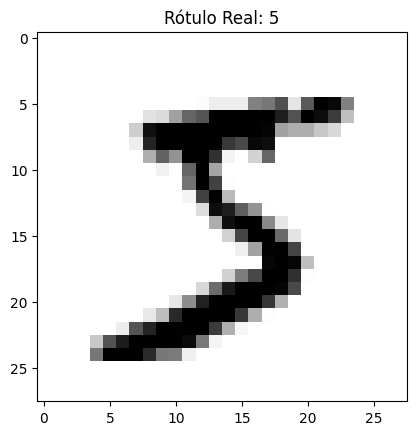

In [8]:
# 3. Agora podemos visualizar o "mosaico" completo
plt.imshow(imagem_2d, cmap="binary")
plt.title(f"Rótulo Real: {mnist.target.iloc[0]}")
#plt.axis("off") # Esconde as réguas laterais
plt.show()

In [9]:
X,y = mnist["data"], mnist["target"]
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


In [10]:
%matplotlib inline

some_digit = X[36000]
some_digit_image = some_digit.reshape(28, 28)

plt.imshow(some_digit_image, cmap=matplotlib.cm.binary, interpolation="nearest")
plt.axis("off")
plt.show

KeyError: 36000

In [11]:
y = pd.DataFrame(y)

In [12]:
X_train, X_test = X.iloc[:60_000,:], X.iloc[60_000:,:]
y_train, y_test =  y.iloc[:60_000,:].astype(np.int64), y.iloc[60_000:,:].astype(np.int64)


In [13]:
shuffle_index = np.random.permutation(60000)
X_train, y_train = X_train.iloc[shuffle_index], y_train.iloc[shuffle_index]

In [14]:
y_train_5 = y_train == 5 # True for all 5s, False for all other digits
y_test_5 = y_test == 5

print(np.unique(y_train_5))

[False  True]


In [ ]:
#instaciar a função para classificação SGDClassifier
sgd_clf =   SGDClassifier(random_state=42)
#Treinar a minha base de treino
sgd_clf.fit(X_train,y_train_5)

/home/psyche/.pyenv/versions/3.10.10/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [30]:
sgd_clf

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [16]:
some_digit = X.iloc[0, :].to_numpy()


In [17]:
some_digit.shape

(784,)

In [18]:
sgd_clf.predict(some_digit.reshape(1, 784))

/home/psyche/.pyenv/versions/3.10.10/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([ True])

In [ ]:
# Medida de performance - Medida de acertos
acuracias = cross_val_score(sgd_clf, X_train, y_train_5, scoring='accuracy', cv=3)

/home/psyche/.pyenv/versions/3.10.10/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/psyche/.pyenv/versions/3.10.10/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/psyche/.pyenv/versions/3.10.10/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [20]:
acuracias

array([0.96245, 0.9606 , 0.96605])

In [21]:
zero_r = DummyClassifier()
zero_r.fit(X_train, y_train_5)

,strategy,'prior'
,random_state,None
,constant,None


In [22]:
acuracias_zero_r = cross_val_score(zero_r, X_train, y_train_5, scoring='accuracy', cv=3)

In [23]:
acuracias_zero_r

array([0.90965, 0.90965, 0.90965])

In [24]:
from sklearn.base import BaseEstimator

class nerver5classifier(BaseEstimator):
    def fit(self, X, y=None):
        pass
    def predict(sefl,X):
        return np.zeros((len(X),1), dtype=bool)

In [25]:
never_5_clf = nerver5classifier()
cross_val_score(never_5_clf, X_train, y_train_5, scoring='accuracy', cv=3)

array([0.911  , 0.90845, 0.9095 ])

In [ ]:
from sklearn.model_selection import cross_val_predict
#Não entendi muito bem se devo usar essa função ao invés do predict()
#Limiar é sempre zero no sklearn
#Vai comparar o score com o limiar
#Calcula o score
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

/home/psyche/.pyenv/versions/3.10.10/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/psyche/.pyenv/versions/3.10.10/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/psyche/.pyenv/versions/3.10.10/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [29]:
y_train_pred

array([False, False, False, ..., False, False, False])

In [28]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5, y_train_pred)

array([[53444,  1135],
       [ 1083,  4338]])

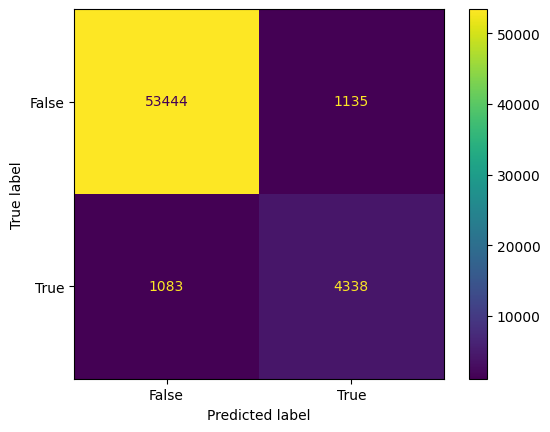

In [32]:
ConfusionMatrixDisplay.from_predictions(y_train_5, y_train_pred)

In [ ]:
# Classificador perfeito, onde as diagonal principal 
# !!!!!!! Entender o porquê da afirmação acima
y_train_perfect_predictions = y_train_5  # pretend we reached perfection
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

Precisão e Revocação

In [34]:
from sklearn.metrics import precision_score, recall_score
precision_score(y_train_5, y_train_pred)

0.792618308057738

In [35]:
recall_score(y_train_5, y_train_pred)

0.8002213613724405

In [36]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)

0.796401689003121

COMPENSAÇÃO DA PRECISÃO/REVOCAÇÃO

In [37]:
y_scores =  sgd_clf.decision_function([some_digit])
y_scores

/home/psyche/.pyenv/versions/3.10.10/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([1618.30165578])

In [38]:
threshold = 0

In [40]:
y_some_digit_pred = (y_scores>threshold)
y_some_digit_pred

array([ True])

In [41]:
threshold = 200000
y_some_digit_pred = (y_scores>threshold)
y_some_digit_pred

array([False])

In [45]:
y_train_5

,class
4853,False
7339,False
10767,False
12869,False
25779,False
...,...
33871,False
26977,False
16406,True
36278,False


In [ ]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")
#Estou tendo um problema interessante em utilizar a função dessa forma:
#   Erro : Only 2 class/es in training fold, but 1 in overall dataset. This is not supported for decision_function with imbalanced folds. To fix this, use a cross-validation technique resulting in properly stratified folds
#   1 - Os dados estão mal distribuidos entre as fatias da validação cruzada
#   2 - A cross_val_predict tentou separar meus dados em três partes(cv=3), mas em uma destas partes, todas as amostras pertenciam a uma única classe.


/home/psyche/.pyenv/versions/3.10.10/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/psyche/.pyenv/versions/3.10.10/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:1367: RuntimeWarning: Number of classes in training fold (2) does not match total number of classes (1). Results may not be appropriate for your use case. To fix this, use a cross-validation technique resulting in properly stratified folds
  warnings.warn(


ValueError: Only 2 class/es in training fold, but 1 in overall dataset. This is not supported for decision_function with imbalanced folds. To fix this, use a cross-validation technique resulting in properly stratified folds